# 03 · Contar la historia

**Bloque 3 de 4 · 50 minutos**

Tenemos la cifra. Ahora hay que convertirla en algo que un directivo pueda
proyectar en un comité y entender en treinta segundos.

**Cuatro gráficos, cuatro preguntas:**

| Gráfico | Pregunta que responde |
|---|---|
| 1 · Desviación por planta | ¿**Cuánto**? ¿Y comparado con qué? |
| 2 · Evolución mensual | ¿**Cuándo** empezó? ¿Puntual o tendencia? |
| 3 · Top centros de costo | ¿**Dónde** está el problema? |
| 4 · Comparación de versiones | ¿Puedo **confiar** en mi propio número? |

Ninguno es decorativo.

---
## 📖 3.0 · Preparar los datos y el primer gráfico

> 🛟 Arrancamos del checkpoint, así que no importa si no terminaste el
> bloque 2.

In [ ]:
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from utils.verificar import verificar

CK = RAIZ / "datos" / "checkpoints"
SALIDAS = RAIZ / "salidas"
SALIDAS.mkdir(exist_ok=True)

variance = pd.read_parquet(CK / "hechos_variance.parquet")

# Colores del curso: rojo = sobregasto, verde = ahorro
ROJO, VERDE, GRIS, AZUL = "#C0392B", "#27AE60", "#7F8C8D", "#2C6FA6"
plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

print(f"{len(variance):,} filas cargadas")
variance.head(3)

576 filas cargadas


,planta,centro_costo,anio,mes,gasto_real,presupuesto,variance,variance_pct
0,Hermosillo,Refacciones,2025,1,78484.75,72600.0,5884.75,8.11
1,Irapuato,Seguridad,2025,2,40109.50,37800.0,2309.50,6.11
2,Irapuato,Fletes,2025,3,69188.50,70200.0,-1011.50,-1.44


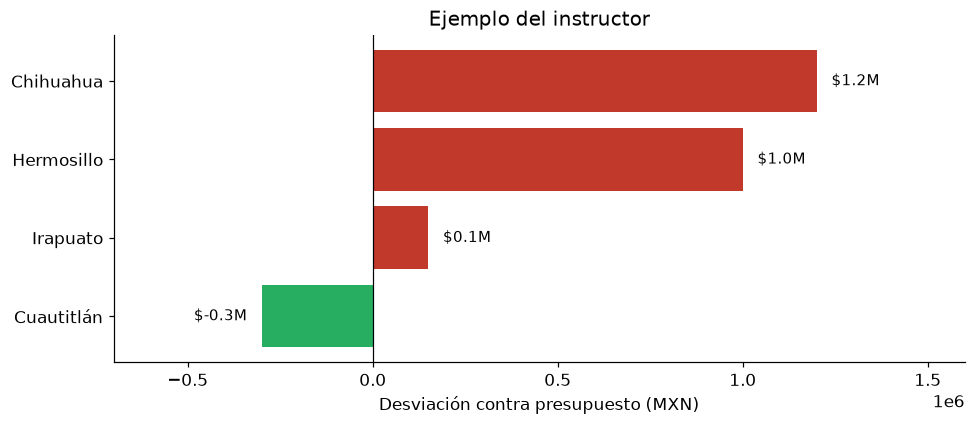

,planta,variance
0,Cuautitlán,-300000.0
1,Irapuato,150000.0
2,Hermosillo,1000000.0
3,Chihuahua,1200000.0


In [ ]:
# Gráfico 1 · desviación por planta en el Q2
por_planta = duckdb.sql("""
    SELECT planta, ROUND(SUM(variance), 2) AS variance
    FROM variance
    WHERE anio = 2026 AND mes BETWEEN 4 AND 6
    GROUP BY planta
    ORDER BY variance
""").df()

fig, ax = plt.subplots(figsize=(9, 4))

# El color codifica el signo: se lee sin tener que mirar los números
colores = [ROJO if v > 0 else VERDE for v in por_planta["variance"]]
ax.barh(por_planta["planta"], por_planta["variance"], color=colores)

ax.axvline(0, color="black", linewidth=0.8)
for i, v in enumerate(por_planta["variance"]):
    ax.text(v + (40_000 if v > 0 else -40_000), i, f"${v/1e6:,.1f}M",
            va="center", ha="left" if v > 0 else "right", fontsize=10)
ax.set_xlim(-700_000, 1_600_000)
ax.set_xlabel("Desviación contra presupuesto (MXN)")
ax.set_title("Ejemplo del instructor")
plt.tight_layout()
plt.show()

por_planta

---
## ✏️ 3.1 · TU TURNO · Ponerle título al gráfico

El gráfico de arriba está bien construido pero es mudo: nadie sabe qué está
viendo. Completa las etiquetas.

El **título** es el ejercicio de verdad. No pongas *"Desviación por planta"*
—eso ya se ve en el gráfico—. Escribe la frase que quieres que el directivo
se lleve.

> 💡 **Pista:** los nombres de planta van en el eje de categorías y la
> desviación en el de magnitud. Para el título: si el directivo leyera solo
> esa línea y nada más, ¿qué necesita saber?

> 👁️ Este ejercicio **no se autocalifica**: un gráfico mal hecho se ve mal.
> Júzgalo con los ojos.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
colores = [ROJO if v > 0 else VERDE for v in por_planta["variance"]]

ax.barh(por_planta["______"], por_planta["________"], color=colores)
#                 ↑ etiquetas          ↑ magnitud

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("________________________________")
ax.set_title("____________________________________________________")

plt.tight_layout()
plt.show()

---
## 🤔 3.2 · ¿Es Hermosillo el problema?

El directivo preguntó por Hermosillo. Mira el gráfico otra vez.

**Responde aquí** (doble clic):

1. ¿Cuál es la planta con mayor sobregasto en el Q2?
2. ¿Le contestarías solo lo que preguntó, o le dirías lo que encontraste?
3. Si mencionas Chihuahua, ¿cómo lo planteas sin que parezca que te desviaste
   del encargo?

> *Escribe aquí tu respuesta…*

---

> 🔑 Parte del trabajo de un analista es **responder la pregunta que
> debieron hacerte**. Pero hay que hacerlo sin dejar sin responder la que sí
> te hicieron.

---
## 📖 3.3 · Gráfico 2 · ¿Puntual o tendencia?

Un total trimestral no distingue entre *"un mes malo"* y *"un problema que
crece"*. Para eso hay que abrir el tiempo.

Aquí usamos los 18 meses, no solo el Q2: sin el antes no se ve el cambio.

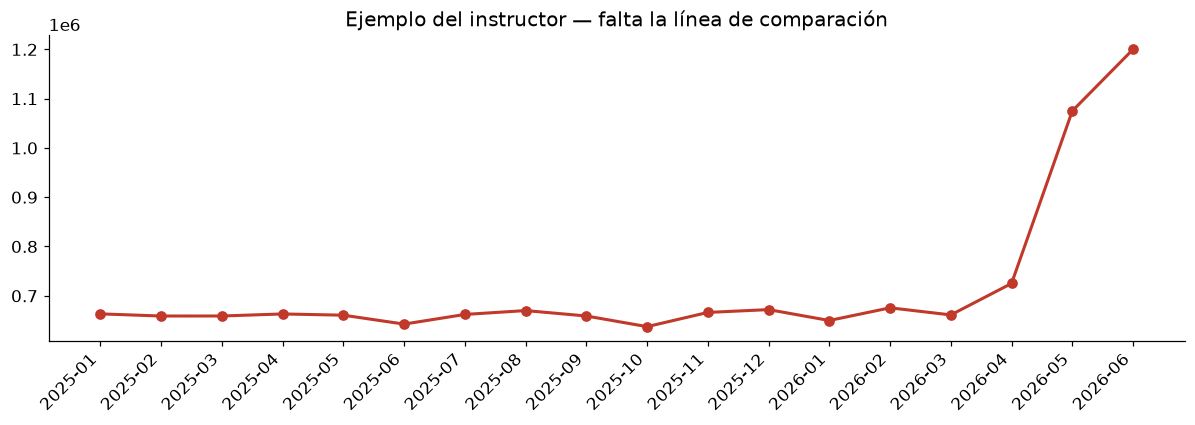

In [ ]:
serie = duckdb.sql("""
    SELECT anio, mes,
           ROUND(SUM(gasto_real), 2)  AS gasto_real,
           ROUND(SUM(presupuesto), 2) AS presupuesto
    FROM variance
    WHERE planta = 'Hermosillo'
    GROUP BY anio, mes
    ORDER BY anio, mes
""").df()
serie["periodo"] = serie["anio"].astype(str) + "-" + serie["mes"].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(serie["periodo"], serie["gasto_real"], marker="o", color=ROJO,
        linewidth=2, label="Gasto real")
ax.set_xticks(range(len(serie)))
ax.set_xticklabels(serie["periodo"], rotation=45, ha="right")
ax.set_title("Ejemplo del instructor — falta la línea de comparación")
plt.tight_layout()
plt.show()

Una sola línea no dice nada: ¿$1.2M al mes es mucho o poco? Falta la
referencia.

---
## ✏️ 3.4 · TU TURNO · Agregar la línea de presupuesto

> 💡 **Pista:** ya tienes la línea del gasto real. Agrega otra igual para el
> presupuesto, y dale `label=` a cada una: sin leyenda, nadie sabe cuál es
> cuál.

> 👁️ Tampoco se autocalifica. Cuando lo tengas, la respuesta a *"¿en qué mes
> empezó?"* debe salir sola.

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(serie["periodo"], serie["gasto_real"], marker="o", color=ROJO,
        linewidth=2, label="_____________")

ax.plot(serie["periodo"], serie["___________"], marker="o", color=GRIS,
        linewidth=2, linestyle="--", label="_____________")

ax.legend()
ax.set_xticks(range(len(serie)))
ax.set_xticklabels(serie["periodo"], rotation=45, ha="right")
ax.set_ylabel("MXN por mes")
ax.set_title("________________________________________________")
plt.tight_layout()
plt.show()

---
## 🤔 3.5 · ¿Puntual o tendencia?

**Responde aquí:**

1. ¿En qué mes se separan las dos líneas?
2. ¿Es un mes aislado o se sostiene?
3. ¿Qué le dices al directivo: *"ya pasó"* o *"sigue abierto"*? El plan de
   acción es completamente distinto según la respuesta.

> *Escribe aquí tu respuesta…*

---
## ✏️ 3.6 · TU TURNO · Gráfico 3 · ¿Dónde está el problema?

Falta la tercera pregunta: **qué centros de costo lo explican.**

> 💡 **Pista:** el directivo quiere los culpables, no los ocho centros.
> Ordena por magnitud de desviación y quédate con los primeros.

In [ ]:
top_centros = duckdb.sql("""
    SELECT centro_costo, ROUND(SUM(variance), 2) AS variance
    FROM variance
    WHERE planta = 'Hermosillo' AND anio = 2026 AND mes BETWEEN 4 AND 6
    GROUP BY centro_costo
    ORDER BY variance ______
    LIMIT __
""").df()

top_centros

In [ ]:
verificar("3.6", top_centros)

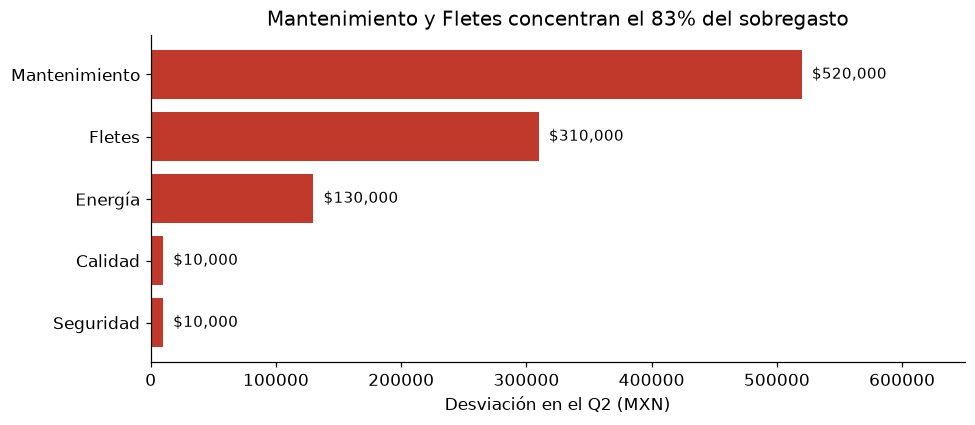

Los 5 centros mostrados explican $980,000.00


In [ ]:
# El dibujo ya está escrito: tú decidiste QUÉ graficar, que es lo que importa
fig, ax = plt.subplots(figsize=(9, 4))
d = top_centros.sort_values("variance")
ax.barh(d["centro_costo"], d["variance"], color=ROJO)
for i, v in enumerate(d["variance"]):
    ax.text(v + 8_000, i, f"${v:,.0f}", va="center", fontsize=10)
ax.set_xlim(0, d["variance"].max() * 1.25)
ax.set_xlabel("Desviación en el Q2 (MXN)")
ax.set_title("Mantenimiento y Fletes concentran el 83% del sobregasto")
plt.tight_layout()
plt.show()

total = top_centros["variance"].sum()
print(f"Los {len(top_centros)} centros mostrados explican ${total:,.2f}")

---
## 🤔 3.7 · ¿Qué centros lo explican?

**Responde aquí:**

1. ¿Cuántos centros de costo hacen falta para explicar la mayor parte de la
   desviación?
2. ¿Qué porcentaje del total representan?
3. ¿A quién le preguntarías primero? (la columna `responsable` del catálogo
   que cargamos en el bloque 1 tiene el nombre)

> *Escribe aquí tu respuesta…*

---
## 📖 3.8 · Un momento… ¿y si no hubiéramos limpiado?

Las tres preguntas están respondidas y el reporte está listo.

Antes de mandarlo, hagamos un experimento: **correr exactamente el mismo
análisis sobre los datos crudos**, los del archivo original, sin la limpieza
del bloque 1.

In [ ]:
# Los datos tal como llegaron: sin deduplicar, sin normalizar el texto
crudos = pd.read_csv(RAIZ / "datos" / "crudos" / "hechos_gasto.csv")
crudos["monto"] = (crudos["monto"].str.replace(".", "", regex=False)
                                  .str.replace(",", ".", regex=False).astype(float))
crudos["anio"] = crudos["fecha"].str[:4].astype(int)
crudos["mes"] = crudos["fecha"].str[5:7].astype(int)

ppto = pd.read_parquet(CK / "presupuesto_limpio.parquet")

v1 = duckdb.sql("""
    WITH real AS (SELECT planta, anio, mes, SUM(monto) AS gasto_real
                  FROM crudos GROUP BY planta, anio, mes),
         p AS (SELECT planta, anio, mes, SUM(monto_presupuesto) AS presupuesto
               FROM ppto GROUP BY planta, anio, mes)
    SELECT real.planta, ROUND(SUM(real.gasto_real - p.presupuesto), 2) AS variance
    FROM real JOIN p
      ON real.planta = p.planta AND real.anio = p.anio AND real.mes = p.mes
    WHERE real.anio = 2026 AND real.mes BETWEEN 4 AND 6
    GROUP BY real.planta ORDER BY variance DESC
""").df()

v2 = por_planta.sort_values("variance", ascending=False).reset_index(drop=True)

print("VERSIÓN 1"); print(v1.to_string(index=False))
print(); print("VERSIÓN 2"); print(v2.to_string(index=False))

VERSIÓN 1
    planta  variance
Hermosillo 4000000.0
 Chihuahua 1200000.0
  Irapuato  150000.0
Cuautitlán -300000.0

VERSIÓN 2
    planta  variance
 Chihuahua 1200000.0
Hermosillo 1000000.0
  Irapuato  150000.0
Cuautitlán -300000.0


In [ ]:
# Las dos versiones se guardan con nombres neutrales, a propósito: eres tú
# quien decide cuál es la correcta. Son archivos de trabajo, no la entrega
# final — la codificación del archivo que sí se entrega se ve en el 3.11.
v1.to_csv(SALIDAS / "reporte_v1.csv", index=False)
v2.to_csv(SALIDAS / "reporte_v2.csv", index=False)
print("Escritos: salidas/reporte_v1.csv  y  salidas/reporte_v2.csv")

Escritos: salidas/reporte_v1.csv  y  salidas/reporte_v2.csv


---
## ✏️ 3.9 · TU TURNO · Gráfico 4 · Las dos versiones juntas

Pon las dos versiones en una sola tabla para poder compararlas de un golpe.

> 💡 **Pista:** necesitas una fila por planta y una columna por versión.
> `merge` sobre `planta`, y usa `suffixes` para distinguir las dos columnas
> de desviación.

In [ ]:
comparativa = v1.merge(v2, on="________", suffixes=("_v1", "_v2"))

comparativa

In [ ]:
verificar("3.9", comparativa)

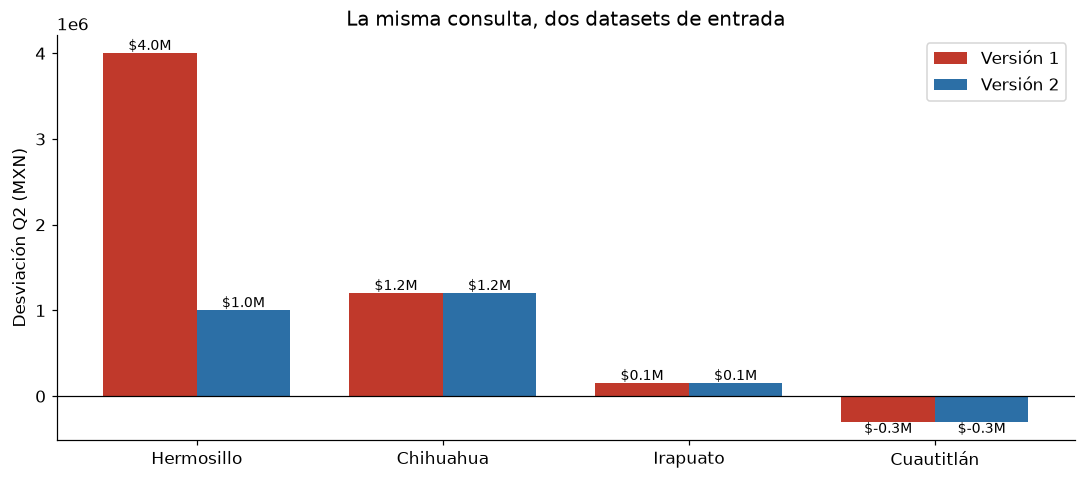

In [ ]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(comparativa))
ancho = 0.38

ax.bar(x - ancho/2, comparativa["variance_v1"], ancho, label="Versión 1", color=ROJO)
ax.bar(x + ancho/2, comparativa["variance_v2"], ancho, label="Versión 2", color=AZUL)

ax.set_xticks(x)
ax.set_xticklabels(comparativa["planta"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Desviación Q2 (MXN)")
ax.set_title("La misma consulta, dos datasets de entrada")
ax.legend()

for i, (a, b) in enumerate(zip(comparativa["variance_v1"], comparativa["variance_v2"])):
    ax.text(i - ancho/2, a, f"${a/1e6:,.1f}M", ha="center",
            va="bottom" if a > 0 else "top", fontsize=9)
    ax.text(i + ancho/2, b, f"${b/1e6:,.1f}M", ha="center",
            va="bottom" if b > 0 else "top", fontsize=9)

plt.tight_layout()
plt.show()

---
## 🎯 3.10 · La pregunta del bloque

Mira el gráfico. Las dos versiones salieron del **mismo código SQL**. La
única diferencia es que una partió de los datos crudos y la otra de los datos
acondicionados.

En la versión 1, Hermosillo aparece con una desviación de **$4.0M** y es, con
mucho, el peor caso. En la versión 2 son **$1.0M** y resulta que **Chihuahua
está peor**.

No es una diferencia de precisión. **Es una conclusión distinta**, sobre una
planta distinta.

---

### ✍️ Responde aquí — es la pregunta más importante del curso

1. **¿Cuál de las dos versiones presentas al comité del viernes?**
   ¿Cómo sabes que es esa? Justifícalo con lo que hiciste en el bloque 1.

2. **Ya enviaste la versión 1 el lunes** y el comité es el viernes. ¿Qué
   haces? Escribe el mensaje que le mandarías al directivo.

3. ¿Qué habría pasado si nadie hubiera revisado los duplicados? ¿Quién se
   habría dado cuenta, y cuándo?

4. ¿Qué control pondrías para que esto no vuelva a pasar el próximo cierre?

> *Escribe aquí tu respuesta…*

---

> 🔑 **Esto es acondicionar datos.** No es un paso técnico previo al análisis
> de verdad: es lo que decide si tu análisis es correcto o es ficción. Los
> $3.0M de diferencia son 800 asientos que se cargaron dos veces — un detalle
> de ETL que a nadie le habría parecido importante.

---
## ✏️ 3.11 · TU TURNO · Exportar el reporte final para Power BI

Ya decidiste cuál versión es la correcta. Ahora hay que entregarla en un
archivo que Power BI lea bien.

Falta un detalle: la codificación **al escribir**.

> 💡 **Pista:** vuelve a la tabla de codificaciones del bloque 1. ¿Cuál se usa
> al **escribir** un archivo que alguien abrirá en Power BI o Excel en
> Windows? No es la misma que se usa al leer.

In [ ]:
reporte_final = duckdb.sql("""
    SELECT planta, centro_costo, anio, mes,
           gasto_real, presupuesto, variance, variance_pct
    FROM variance
    WHERE anio = 2026 AND mes BETWEEN 4 AND 6
    ORDER BY planta, centro_costo, mes
""").df()

reporte_final.to_csv(
    SALIDAS / "reporte_final_powerbi.csv",
    index=False,
    encoding="___________",
)

print(f"{len(reporte_final):,} filas escritas")
reporte_final.head()

In [ ]:
verificar("3.11", reporte_final)

In [ ]:
# Por qué el "-sig": comprueba el efecto tú mismo
ruta = SALIDAS / "reporte_final_powerbi.csv"
crudo = ruta.read_bytes()

print(f"¿Empieza con BOM?  {crudo[:3] == b'\xef\xbb\xbf'}")
print()
print("Así lee Power BI en Windows un archivo SIN BOM:")
sin_bom = "Nómina Indirecta".encode("utf-8").decode("cp1252")
print(f"   {sin_bom}")
print("Así lo lee CON BOM (utf-8-sig):")
print(f"   Nómina Indirecta")

¿Empieza con BOM?  True

Así lee Power BI en Windows un archivo SIN BOM:
   NÃ³mina Indirecta
Así lo lee CON BOM (utf-8-sig):
   Nómina Indirecta


Sin el BOM, Power BI en Windows asume cp1252 y te muestra `NÃ³mina
Indirecta`. Con el BOM, sabe que es UTF-8.

Es un detalle de tres caracteres que decide si tu reporte se ve profesional o
roto.

> **Aquí termina el alcance del curso.** El archivo está listo para
> `Obtener datos → Texto/CSV` en Power BI. Construir el tablero es otro tema.

---
## 📖 3.12 · Volvamos al correo

Releamos la petición del lunes:

> *"Necesito entender por qué el gasto de Hermosillo se disparó en el Q2.
> Quiero saber si es algo puntual o una tendencia, y qué centros de costo lo
> explican. Mándame algo que pueda proyectar."*

In [ ]:
print("═" * 66)
print("  ¿RESPONDIMOS LA PETICIÓN?".center(66))
print("═" * 66)
for pregunta, donde in [
    ("¿Cuánto se disparó?",          "Gráfico 1 + tabla de desviación"),
    ("¿Puntual o tendencia?",        "Gráfico 2 — arranca en mayo, sigue abierto"),
    ("¿Qué centros lo explican?",    "Gráfico 3 — Mantenimiento y Fletes"),
    ("¿Algo que pueda proyectar?",   "4 gráficos + reporte_final_powerbi.csv"),
]:
    print(f"  ✅  {pregunta:<30} {donde}")
print("─" * 66)
print("  Y algo que no preguntó:")
print("  ⚠️   Chihuahua excede su presupuesto más que Hermosillo")
print("═" * 66)

══════════════════════════════════════════════════════════════════
                     ¿RESPONDIMOS LA PETICIÓN?                    
══════════════════════════════════════════════════════════════════
  ✅  ¿Cuánto se disparó?            Gráfico 1 + tabla de desviación
  ✅  ¿Puntual o tendencia?          Gráfico 2 — arranca en mayo, sigue abierto
  ✅  ¿Qué centros lo explican?      Gráfico 3 — Mantenimiento y Fletes
  ✅  ¿Algo que pueda proyectar?     4 gráficos + reporte_final_powerbi.csv
──────────────────────────────────────────────────────────────────
  Y algo que no preguntó:
  ⚠️   Chihuahua excede su presupuesto más que Hermosillo
══════════════════════════════════════════════════════════════════


---

# ✅ Bloque 3 terminado

Recorriste el flujo completo: **petición ambigua → datos sucios → análisis →
narrativa → entrega**.

Y lo más importante que te llevas no es un gráfico: es que **la misma
consulta sobre datos sin acondicionar te habría hecho reportar $4.0M en la
planta equivocada.**

---

## 🎯 Ahora ve al reto — Paso 3 y entrega

Abre **`04_reto_final.ipynb`**, haz el **Paso 3** (10 min) y luego cierra tu
conclusión y entrega (20 min).

Ojo con la pregunta del reto: **no es la misma que aquí.**